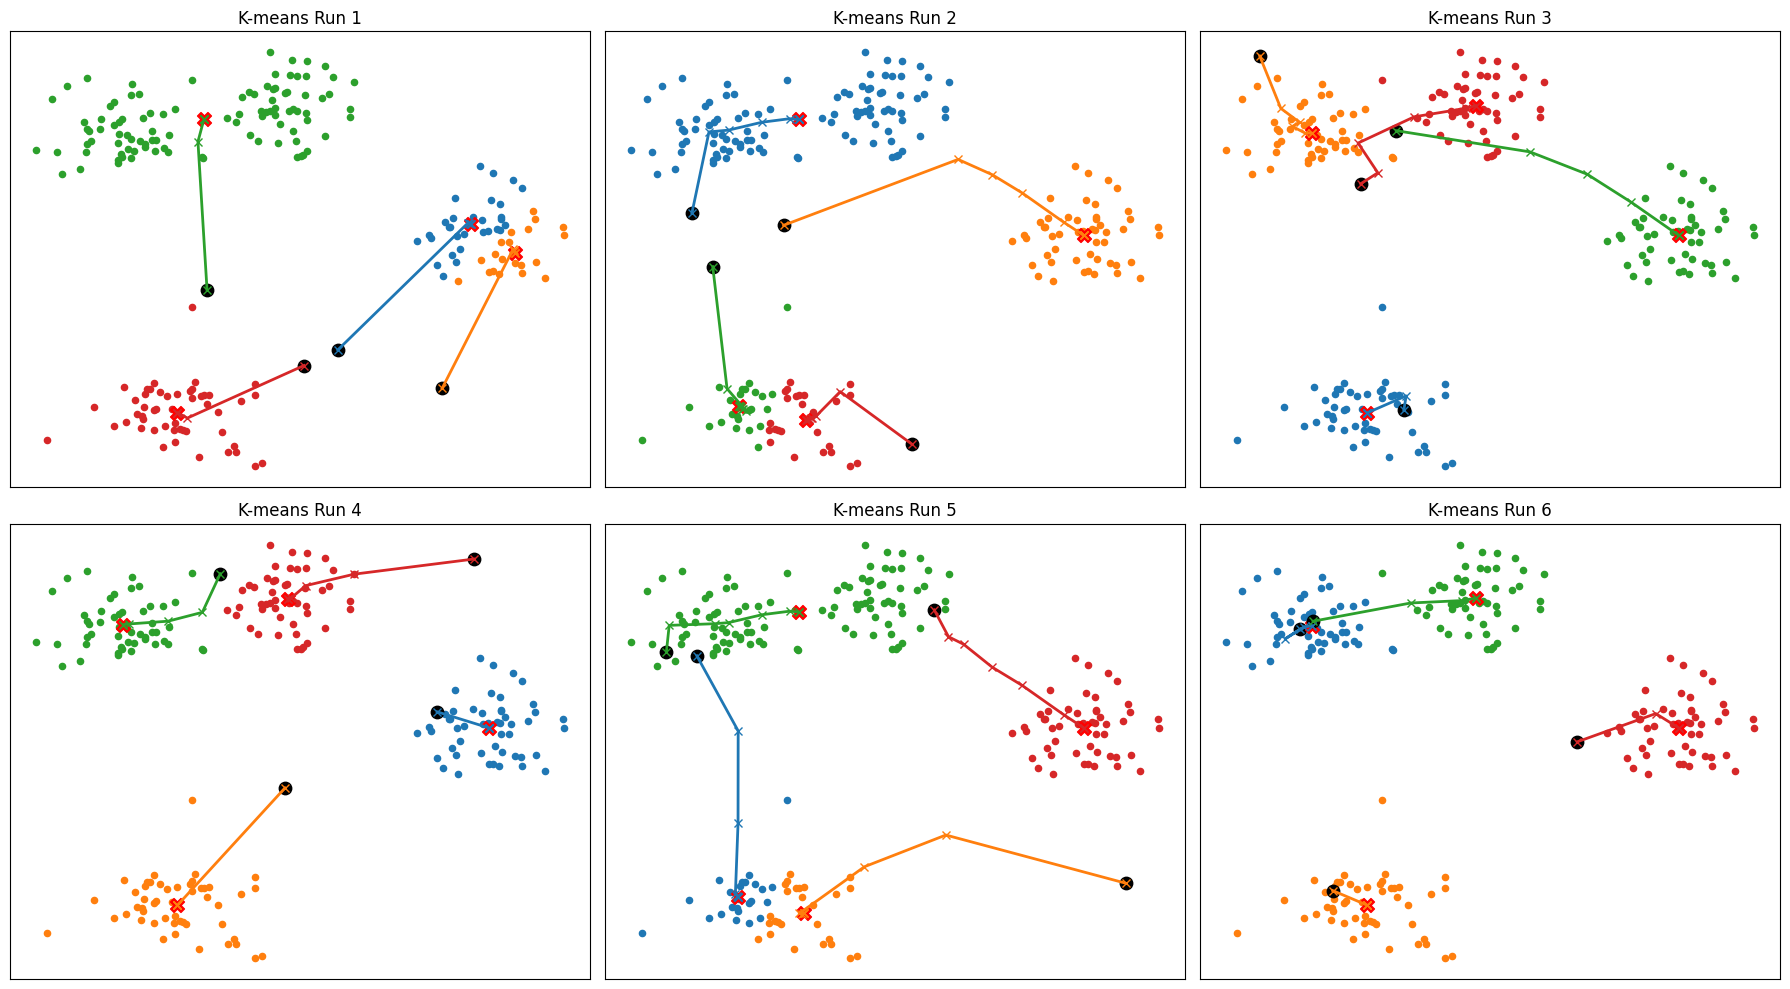

In [3]:
# KMeans "almost" always converges. Let's try to run k-means a few times,
# and each time to plot the final cluster centroid positions, along with their
# starting points

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ----- Generate synthetic data -----
np.random.seed(42)
X, _ = make_blobs(
    n_samples=200,
    centers=4,
    cluster_std=1.4
)

# ----- Parameters -----
k = 4
max_iters = 30
runs = 6  # Updated number of runs


def initialize_centroids(X, k):
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    return np.random.uniform(mins, maxs, size=(k, X.shape[1]))


def assign_clusters(X, centroids):
    distances = np.linalg.norm(
        X[:, np.newaxis] - centroids,
        axis=2
    )
    return np.argmin(distances, axis=1)


def update_centroids(X, labels, k):
    return np.array([
        X[labels == i].mean(axis=0)
        for i in range(k)
    ])


# ----- Plotting Function -----
def run_kmeans_and_plot(run_idx):
    centroids = initialize_centroids(X, k)
    centroid_history = [centroids.copy()]

    for i in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        centroid_history.append(new_centroids.copy())

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    # Plot
    ax = plt.subplot(2, 3, run_idx + 1)
    ax.set_title(f"K-means Run {run_idx + 1}")

    for j in range(k):
        ax.scatter(
            X[labels == j][:, 0],
            X[labels == j][:, 1],
            s=20,
            label=f"Cluster {j}"
        )

    for c in range(k):
        path = np.array([step[c] for step in centroid_history])

        ax.plot(
            path[:, 0],
            path[:, 1],
            marker="x",
            markersize=6,
            linewidth=2
        )

        ax.scatter(
            path[0, 0],
            path[0, 1],
            c="black",
            marker="o",
            s=80
        )

        ax.scatter(
            path[-1, 0],
            path[-1, 1],
            c="red",
            marker="X",
            s=100
        )

    ax.set_xticks([])
    ax.set_yticks([])


# ----- Run All and Plot -----
plt.figure(figsize=(18, 10))

for run in range(runs):
    run_kmeans_and_plot(run)

plt.tight_layout()
plt.show()